# Lecture 15 Diffusion Model

# 一、 生成模型理论基础与回顾

在深入扩散模型之前，首先需要理解其理论前身——**变分自编码器（VAE）**及其局限性，从而引出分层 VAE 与扩散模型的关系。

### 1. 标准变分自编码器 (VAE) 回顾
*   **生成目标**：给定真实数据分布 $x \sim p_{\text{data}}(x)$ 和隐变量 $z$，生成模型的目标是最大化边际似然的期望：
    $$\max_\theta \mathbb{E}_{x \sim p_{\text{data}}} [\log p_\theta(x)]$$
    其中，生成分布定义为：
    $p_\theta(x) = \int_z p_\theta(x|z)p(z)dz$
*   **引入变分后验**：由于真实的后验分布 $p_\theta(z|x)$ 难以计算（Intractable），VAE 引入一个可学习的变分近似后验分布 $q_\phi(z|x)$。
*   **证据下界 (ELBO) 推导**：利用 **Jensen 不等式**（若 $f$ 为凹函数，则 $f(\mathbb{E}[X]) \ge \mathbb{E}[f(X)]$），将 $\log$ 放入积分/期望内部：
    $$\log p_\theta(x) = \log \int_z q_\phi(z|x) \frac{p_\theta(x|z)p(z)}{q_\phi(z|x)} dz = \log \mathbb{E}_{z \sim q_\phi(z|x)} \left[ \frac{p_\theta(x|z)p(z)}{q_\phi(z|x)} \right]$$
    $$\ge \mathbb{E}_{z \sim q_\phi(z|x)} \left[ \log \frac{p_\theta(x|z)p(z)}{q_\phi(z|x)} \right] \quad \text{(ELBO)}$$

### 2. 单层隐变量的局限性
*   在单层 VAE 中，模型结构为 $z \to x$。
*   这意味着**单个隐特征向量 $z$ 必须同时捕获所有的层级信息**：包括物体的类别、整体形状、姿态、纹理以及极其微小的细节。在实际应用中，让单一特征向量承载如此多维度的信息是非常困难的，容易导致生成图像模糊或缺乏细节。

### 3. 分层变分自编码器 (Hierarchical VAEs)
为了解决单层隐变量的局限性，分层 VAE 引入了多个隐变量（以两个隐变量 $z_1, z_2$ 为例，构成马尔可夫链 $x \leftarrow z_1 \leftarrow z_2$）：
*   **联合概率分布（生成模型）**：
    $p(x, z_1, z_2) = p(x|z_1)p(z_1|z_2)p(z_2)$
*   **近似后验分布（推断模型）**：
    $q(z_1, z_2|x) = q(z_1|x)q(z_2|z_1)$
*   **对应的证据下界 (ELBO)**：
    将上述因式分解代入下界公式，可整理为：
    $$\mathcal{L}(\theta, \phi) = \mathbb{E}_{q(z_1|x)} [\log p(x|z_1)] - D_{KL}(q(z_1|x) \parallel p(z_1|x)) - D_{KL}(q(z_2|z_1) \parallel p(z_2))$$
    *   **物理意义**：该下界包含了一个**重构项**（从 $z_1$ 重构 $x$），以及**每一层推断层与其对应先验层之间的 KL 散度约束**。通过设计更长的隐变量链，模型可以分层分阶段地捕获从宏观到微观的特征。

---

# 二、 扩散概率模型（DPM / DDPM）

**扩散模型**可以被视作一种特殊形式的**分层 VAE（Hierarchical VAE）**，其中包含了一系列长度为 $T$ 的隐变量序列 $x_{1:T}$。

### 1. 核心差异与特点
相比于传统的分层 VAE，扩散模型拥有两个独特的性质：
1.  **无参数推断**：前向过程（加噪过程）由人工定义，**不包含任何可学习的参数**。
2.  **终态收敛**：加噪的设计使得当 $T$ 足够大时，最终的隐变量分布 $x_T$ 必然收敛于标准高斯分布 $\mathcal{N}(0, I)$。

### 2. 前向扩散过程 (Forward Diffusion Process)
前向过程通过在每个时间步添加微小的高斯噪声，将真实数据 $x_0$ 逐渐破坏为纯噪声：
*   **单步转移概率**：
    $$q(x_t|x_{t-1}) = \mathcal{N}(x_t; \sqrt{1-\beta_t}x_{t-1}, \beta_t I)$$
    其中 $\beta_t \in (0, 1)$ 是预先设计的**方差调度参数（Variance Schedule）**。
*   **直接重采样公式 (Diffusion Kernel)**：
    利用高斯分布的叠加性质（若独立变量 $X \sim \mathcal{N}(\mu_1, \Sigma_1)$，$Y \sim \mathcal{N}(\mu_2, \Sigma_2)$，则 $X+Y \sim \mathcal{N}(\mu_1+\mu_2, \Sigma_1+\Sigma_2)$），前向过程可以递归展开。通项公式推导过程：
    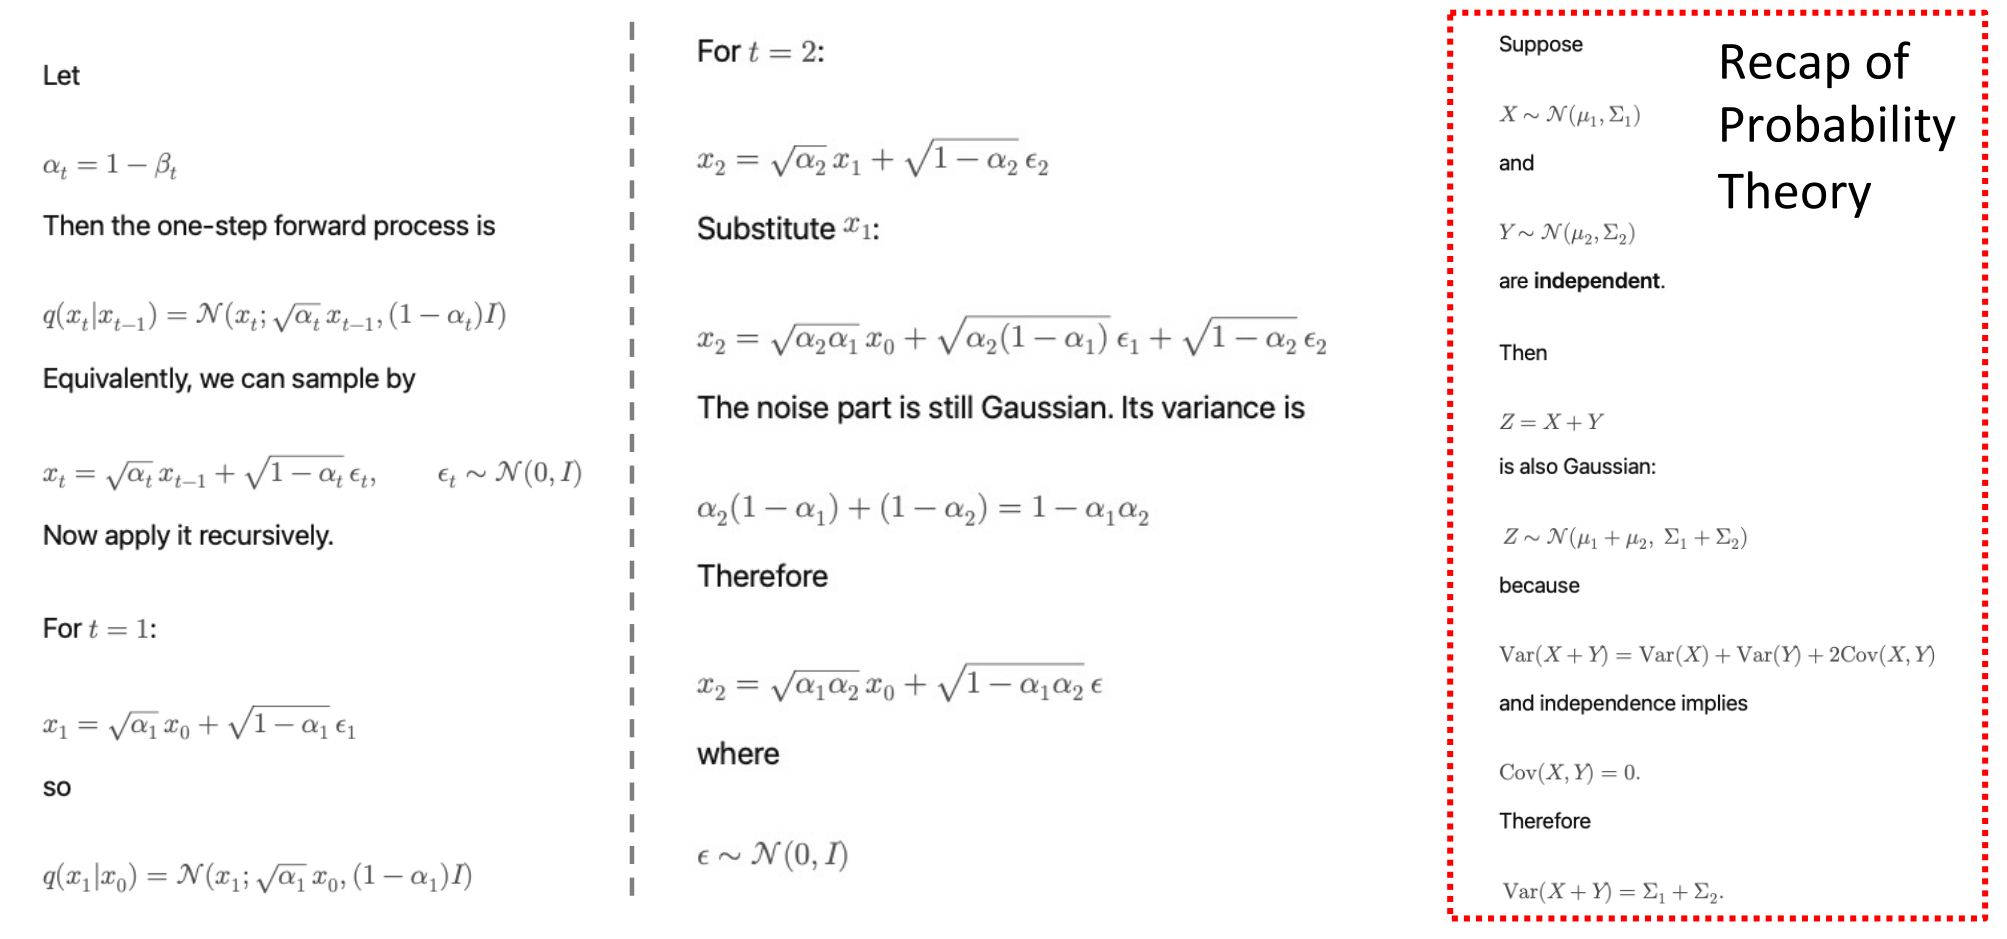
    令 $\alpha_t = 1 - \beta_t$，并定义累乘系数 $\bar{\alpha}_t = \prod_{s=1}^t \alpha_s$，我们可以直接从 $x_0$ 采样出任意步骤的 $x_t$：
    $$x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\epsilon, \quad \text{其中 } \epsilon \sim \mathcal{N}(0, I)$$
    因此，前向加噪的解析核为：
    $$q(x_t|x_0) = \mathcal{N}(x_t; \sqrt{\bar{\alpha}_t}x_0, (1-\bar{\alpha}_t)I)$$
*   **方差调度设计（以 DDPM 为例）**：
    *   设置 $T = 1000$，$\beta_{\text{min}} = 10^{-4}$，$\beta_{\text{max}} = 0.02$。
    *   其对应的 $\bar{\alpha}_t$ 近似演变规律为：
        *   $\bar{\alpha}_0 = 1$（无噪声）
        *   $\bar{\alpha}_{100} \approx 0.90$
        *   $\bar{\alpha}_{300} \approx 0.39$
        *   $\bar{\alpha}_{500} \approx 0.078$
        *   $\bar{\alpha}_{700} \approx 0.0069$
        *   $\bar{\alpha}_{1000} \approx 4.0 \times 10^{-5} \approx 0$（几乎完全变为标准高斯噪声 $x_T \sim \mathcal{N}(0, I)$）
*   **前向过程的数学本质**：前向过程在分布层面相当于**高斯卷积（Gaussian Convolution）**。随着 $t$ 增大，高频细节分布首先被平滑，分布逐渐向单峰的标准高斯分布靠拢。

### 3. 反向去噪过程 (Reverse Denoising Process)
反向过程的目标是从标准高斯噪声 $x_T \sim \mathcal{N}(0, I)$ 出发，逐步生成无噪数据 $x_0$：
*   **小步转移近似**：当单步变化的步长 $\beta_t$ 极小时，反向转移概率 $q(x_{t-1}|x_t)$ 同样近似为高斯分布。
*   **参数化建模**：由于真实的反向转换 $q(x_{t-1}|x_t)$ 无法直接求解，我们使用神经网络 $p_\theta(x_{t-1}|x_t)$ 来对其进行逼近：
    $$p_\theta(x_{t-1}|x_t) = \mathcal{N}(x_{t-1}; \mu_\theta(x_t, t), \Sigma_\theta(x_t, t))$$
    在常用的 DDPM 设定中，方差项常固定为 $\Sigma_\theta(x_t, t) = \sigma_t^2 I$（例如设为 $\beta_t$ 或下文提到的 $\tilde{\beta}_t$），只让网络预测均值 $\mu_\theta(x_t, t)$。